In [1]:
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
united = Table().read_table('data/united.csv')



In [3]:
start = np.random.choice(np.arange(1000))
random_samples = united.take(np.arange(start, start + 100))

In [4]:
random_samples

Date,Flight Number,Destination,Delay
6/2/15,705,ORD,0
6/2/15,714,LAS,34
6/2/15,715,PHX,14
6/2/15,718,SAN,-2
6/2/15,720,DEN,-2
6/2/15,721,DFW,-7
6/2/15,728,ORD,7
6/2/15,753,LAS,16
6/2/15,756,DEN,-2
6/2/15,758,JFK,26


In [5]:
random_sample2 = united.sample(k = 5, with_replacement=False)
random_sample2

Date,Flight Number,Destination,Delay
8/13/15,1857,DEN,-7
7/12/15,620,ORD,-6
6/12/15,1721,KOA,-2
8/4/15,361,LIH,0
8/17/15,502,JFK,11


## Distributions

In [6]:
die = Table().with_column('Face', np.arange(1, 7))
die

Face
1
2
3
4
5
6


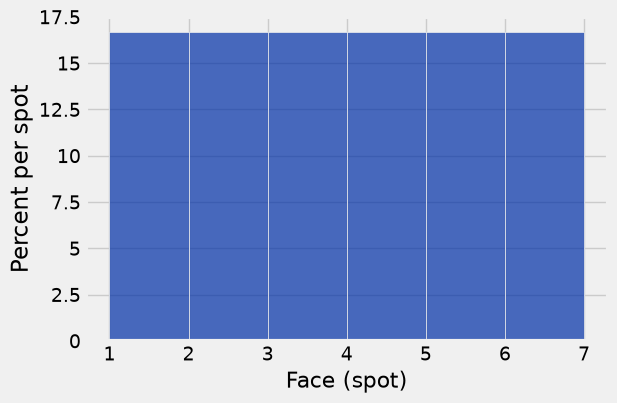

In [7]:
die.hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit='spot')

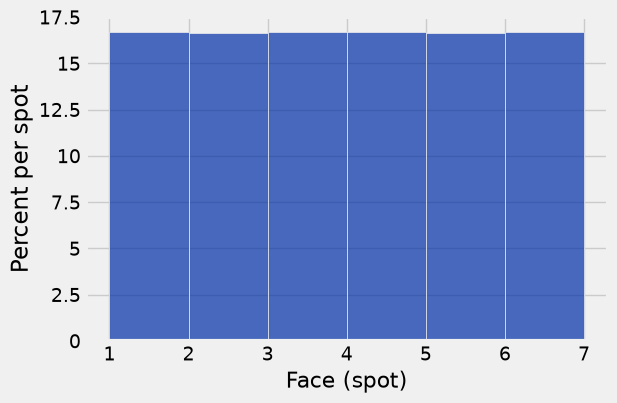

In [8]:
die.sample(10000000).hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit='spot')

# Distribution of selay on United flights

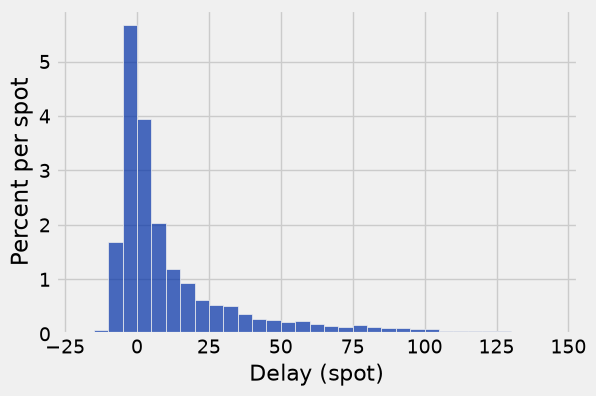

In [9]:
united_bins = np.arange(-20, 150, 5)
united.hist('Delay', bins = united_bins, unit='spot')

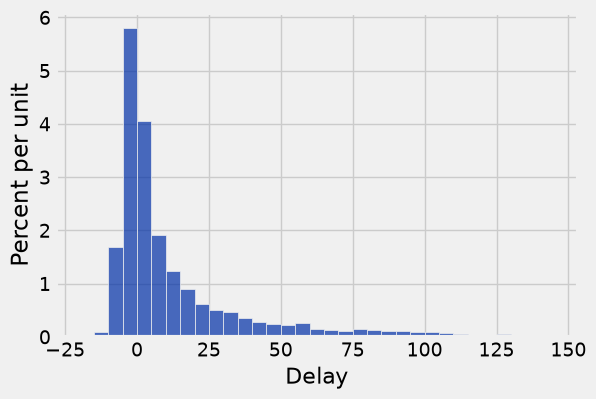

In [10]:
# Sample a few
united.sample(10000).hist('Delay', bins=united_bins)

In [11]:
np.median(united.column("Delay")), np.mean(united.column("Delay")), np.max(united.column("Delay")), np.min(united.column("Delay"))

(np.float64(2.0), np.float64(16.658155515370705), np.int64(580), np.int64(-16))

In [13]:
def observed_sample_median(sample_size):
    return np.median(united.sample(sample_size).column('Delay'))

def run_sim(simulation_count, sample_size):
    observed_sample_medians = np.zeros(simulation_count)
    
    for i in np.arange(simulation_count):
        observed_sample_medians[i] = observed_sample_median(sample_size)

    return observed_sample_medians

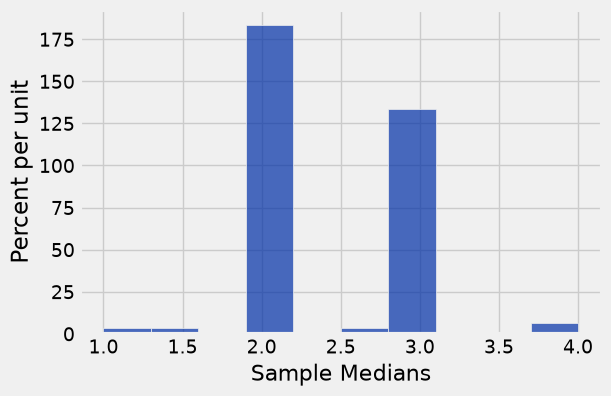

In [14]:
results = run_sim(100, 1000)
Table().with_columns("Sample Medians", results).hist()